<a href="https://colab.research.google.com/github/adaryass/Financial-applications-with-Python/blob/main/Optimisation_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

/tmp/ipykernel_295/2674037259.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ptf_assets[ticker] = yf.download(ticker, start = str_year_prior, end = str_today, interval = '1wk')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_295/2674037259.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ptf_assets[ticker] = yf.download(ticker, start = str_year_prior, end = str_today, interval = '1wk')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_295/2674037259.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ptf_assets[ticker] = yf.download(ticker, start = str_year_prior, end = str_today, interval = '1wk')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_295/2674037259.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True


<function matplotlib.pyplot.show(close=None, block=None)>

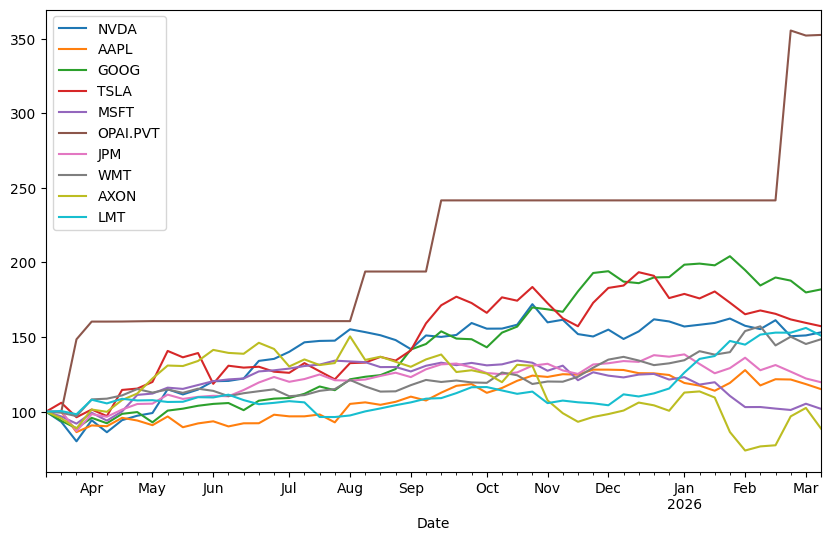

In [3]:
#choosing stock list
list_tickers = ['NVDA', 'AAPL', 'GOOG','TSLA','MSFT','OPAI.PVT', 'JPM', 'WMT', 'AXON', 'LMT']
ptf_assets = pd.DataFrame()
today_date = datetime.today()
year_prior = today_date - timedelta(weeks = 52)
str_today = today_date.strftime("%Y-%m-%d")
str_year_prior = year_prior.strftime("%Y-%m-%d")

#download prices
for ticker in list_tickers:
       ptf_assets[ticker] = yf.download(ticker, start = str_year_prior, end = str_today, interval = '1wk')['Close']
(ptf_assets/ptf_assets.iloc[0] * 100).plot(figsize = (10,6))
plt.show

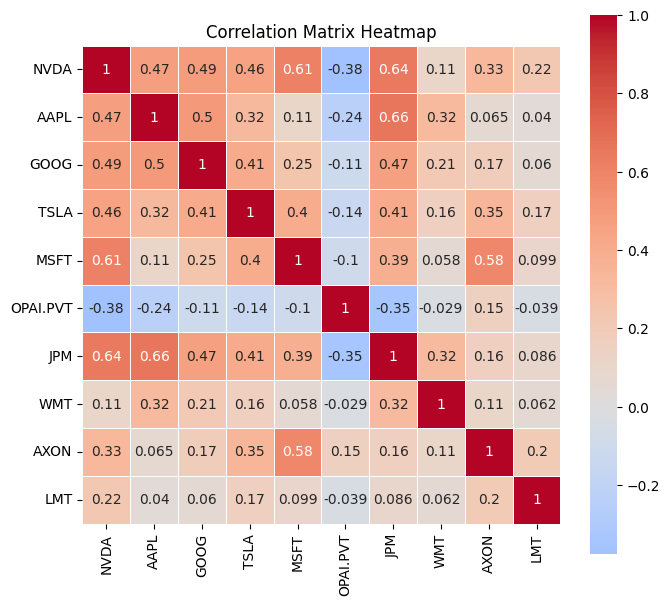

In [9]:
#log returns
asset_returns = np.log(ptf_assets/ptf_assets.shift(1))
#annualizing returns
retuns_annual = asset_returns.mean() * 52
#standard deviation of returns
asset_risks = asset_returns.std() * np.sqrt(52)
#covariance matrix
ptf_covariance = asset_returns.cov()
#correlation matrix
ptf_correlation = asset_returns.corr()
#plotting correlation heatmap
plt.figure(figsize=(7, 8))
sns.heatmap( ptf_correlation,
            annot=True,
            cmap = 'coolwarm',
            center=0,
            linewidths = 0.5,
            square = True,
            cbar_kws={"shrink": 0.7})  # réduit la taille de la colorbar
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

In [12]:
#set empty series to store the monte carlo iteration data
portfolio_returns = []
portfolio_volatility = []
portfolio_weights = []

for x in range(1000000):
    #assing random weights
    weights = np.random.uniform(0, 1, ptf_assets.shape[1])
    #weights as a condition that their sum should be equal to 1
    weights /= np.sum(weights)
    #calculate portfolio returns
    portfolio_returns.append(np.dot(weights,retuns_annual))
    #calculate portfolio volatility
    portfolio_volatility.append(np.sqrt(np.dot(weights.T,np.dot(ptf_covariance * 52 ,weights))))
    #append the weights
    portfolio_weights.append(weights)
portfolio_returns = np.array(portfolio_returns)
portfolio_volatility = np.array(portfolio_volatility)
porftolio_weights = np.array(portfolio_weights)

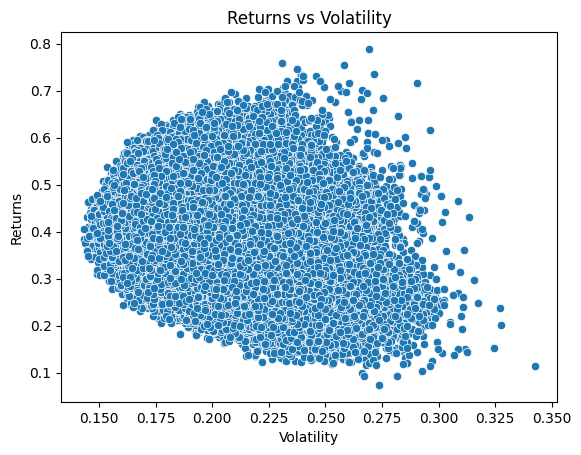

In [13]:
#plot the mean variance universe
portfolios = pd.DataFrame({ 'returns' : portfolio_returns, 'volatility' : portfolio_volatility, 'weights' : list(portfolio_weights)})
sns.scatterplot(x = 'volatility', y = 'returns', data = portfolios)
plt.title('Returns vs Volatility')
plt.xlabel('Volatility')
plt.ylabel('Returns')
plt.show()

In [14]:
portfolios

,returns,volatility,weights
0,0.273546,0.204364,"[0.11842023425208954, 0.236428065672439, 0.032..."
1,0.440030,0.197721,"[0.18752961189037545, 0.09521837417824074, 0.0..."
2,0.302612,0.201689,"[0.15744007794301015, 0.14458646566146477, 0.0..."
3,0.487207,0.169118,"[0.03289348975262313, 0.1250247097915467, 0.07..."
4,0.369547,0.175663,"[0.022813775549463556, 0.06354141756657421, 0...."
...,...,...,...
999995,0.225858,0.234502,"[0.10852393724691722, 0.09384896412885366, 0.0..."
999996,0.558097,0.202000,"[0.08216807095731313, 0.10401006827836042, 0.0..."
999997,0.242305,0.214046,"[0.06252475000588495, 0.18948920322390714, 0.0..."
999998,0.409319,0.180697,"[0.12366503751847599, 0.0969490232459165, 0.10..."


# min Variance

In [26]:
#determine the min var portfollio
optimal_portfolio_volatility = portfolios['volatility'].min()
placement = portfolios[portfolios['volatility'] == optimal_portfolio_volatility]['returns']
placement2 = portfolios[portfolios['volatility'] == optimal_portfolio_volatility]['weights']
optimal_portfolio_return = placement.values[0]
optimal_portfolio_weights = placement2.values[0]
#min var portfolio weights
optimal_assets_weights = pd.DataFrame(optimal_portfolio_weights, index = list_tickers, columns = ["Optimal Weights"])



print('Rentabilité annuelle du portefeuille :', optimal_portfolio_return)
print()
print('Volatilité annuelle du portefeuille :', optimal_portfolio_volatility)
print()
optimal_assets_weights

Rentabilité annuelle du portefeuille : 0.3834502908098554

Volatilité annuelle du portefeuille : 0.14324955348219076



,Optimal Weights
NVDA,0.013922
AAPL,0.094440
GOOG,0.020996
TSLA,0.019109
MSFT,0.182329
OPAI.PVT,0.105550
JPM,0.113062
WMT,0.246688
AXON,0.004960
LMT,0.198946


In [25]:
import plotly.express as px

# 1. Préparation des données
# On utilise votre DataFrame 'optimal_assets_weights'
# On s'assure que l'index (les tickers) est une colonne pour Plotly
df_plot = optimal_assets_weights.reset_index()
df_plot.columns = ['Ticker', 'Poids']

# 2. Création du graphique dynamique
fig = px.pie(
    df_plot,
    values='Poids',
    names='Ticker',
    title='Composition Dynamique du Portefeuille (Min Var)',
    hole=0.5, # Crée l'effet Donut
    color_discrete_sequence=px.colors.qualitative.Pastel
)

# 3. Personnalisation du survol (hover) et du texte
fig.update_traces(
    textposition='inside',
    textinfo='percent+label',
    hovertemplate="<b>%{label}</b><br>Poids: %{value:.2%}<extra></extra>"
)

# 4. Mise en forme du layout
fig.update_layout(
    annotations=[dict(text='Min Var', x=0.5, y=0.5, font_size=20, showarrow=False)],
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=-0.1, xanchor="center", x=0.5)
)

fig.show()

## Ratio de Sharpe

In [27]:
#retrieving the risk free rate
risk_free = yf.download("^TNX", start = str_year_prior, end = str_today, interval = "1wk")['Close']
rf = (risk_free/100).mean()

/tmp/ipykernel_295/630092469.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [28]:
#calculating the sharp ratio
portfolios['Sharpe ratio'] = (portfolios['returns'] - rf.values) / portfolios['volatility']
#max sharp porftolio
max_sharp = portfolios[portfolios['Sharpe ratio'] == portfolios['Sharpe ratio'].max()]
max_sharp_weights = pd.DataFrame(max_sharp['weights'].values[0], index = list_tickers, columns=['Max Sharp Weights'])

In [31]:
portfolios

,returns,volatility,weights,Sharpe ratio
0,0.273546,0.204364,"[0.11842023425208954, 0.236428065672439, 0.032...",1.131847
1,0.440030,0.197721,"[0.18752961189037545, 0.09521837417824074, 0.0...",2.011887
2,0.302612,0.201689,"[0.15744007794301015, 0.14458646566146477, 0.0...",1.290969
3,0.487207,0.169118,"[0.03289348975262313, 0.1250247097915467, 0.07...",2.631120
4,0.369547,0.175663,"[0.022813775549463556, 0.06354141756657421, 0....",1.863277
...,...,...,...,...
999995,0.225858,0.234502,"[0.10852393724691722, 0.09384896412885366, 0.0...",0.783027
999996,0.558097,0.202000,"[0.08216807095731313, 0.10401006827836042, 0.0...",2.553764
999997,0.242305,0.214046,"[0.06252475000588495, 0.18948920322390714, 0.0...",0.934695
999998,0.409319,0.180697,"[0.12366503751847599, 0.0969490232459165, 0.10...",2.031479


In [ ]:
max_sharp

,returns,volatility,weights,Sharpe ratio
95703,0.433063,0.192719,"[0.00743140896822415, 0.051358731961742135, 0....",2.025757


In [32]:
max_sharp_weights

,Max Sharp Weights
NVDA,0.057850
AAPL,0.009543
GOOG,0.251026
TSLA,0.024234
MSFT,0.038170
OPAI.PVT,0.220732
JPM,0.003236
WMT,0.175083
AXON,0.000654
LMT,0.219471


In [33]:
import plotly.express as px

# 1. Préparation des données
# On utilise votre DataFrame 'max_sharp_weights'
# On s'assure que l'index (les tickers) est une colonne pour Plotly
df_plot = max_sharp_weights.reset_index()
df_plot.columns = ['Ticker', 'Poids']

# 2. Création du graphique dynamique
fig = px.pie(
    df_plot,
    values='Poids',
    names='Ticker',
    title='Composition Dynamique du Portefeuille (Max Sharpe)',
    hole=0.5, # Crée l'effet Donut
    color_discrete_sequence=px.colors.qualitative.Pastel
)

# 3. Personnalisation du survol (hover) et du texte
fig.update_traces(
    textposition='inside',
    textinfo='percent+label',
    hovertemplate="<b>%{label}</b><br>Poids: %{value:.2%}<extra></extra>"
)

# 4. Mise en forme du layout
fig.update_layout(
    annotations=[dict(text='Max Sharpe', x=0.5, y=0.5, font_size=20, showarrow=False)],
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=-0.1, xanchor="center", x=0.5)
)

fig.show()

In [35]:
# Sort by volatility
portfolios = portfolios.sort_values(by='volatility')

# Efficient frontier: keep portfolios with max return so far
efficient_frontier = portfolios.loc[
    portfolios['returns'].cummax() == portfolios['returns']
]

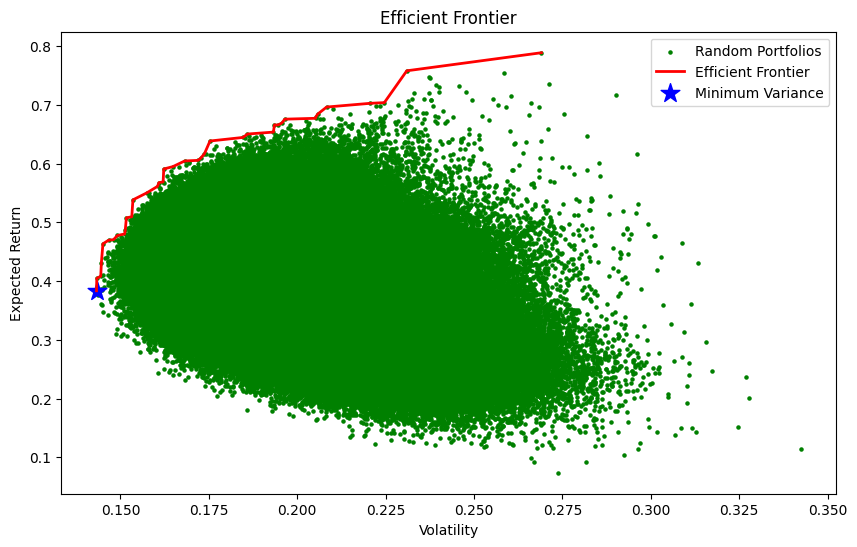

In [36]:
plt.figure(figsize=(10,6))

# Monte Carlo cloud
plt.scatter(
    portfolios['volatility'],
    portfolios['returns'],
    c='green',
    s=5,
    label='Random Portfolios'
)

# Efficient Frontier
plt.plot(
    efficient_frontier['volatility'],
    efficient_frontier['returns'],
    color='red',
    linewidth=2,
    label='Efficient Frontier'
)

# Minimum variance portfolio
plt.scatter(
    optimal_portfolio_volatility,
    optimal_portfolio_return,
    color='blue',
    marker='*',
    s=200,
    label='Minimum Variance'
)

plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.legend()
plt.show()


In [37]:
#retrieving the risk free rate
risk_free = yf.download("^TNX", start = str_year_prior, end = str_today, interval = "1wk")['Close']
rf = float((risk_free/100).mean())
#calculating the sharp ratio
portfolios['Sharpe ratio'] = (portfolios['returns'] - rf) / portfolios['volatility']
#max sharp porftolio
max_sharp = portfolios[portfolios['Sharpe ratio'] == portfolios['Sharpe ratio'].max()]
max_sharp_weights = pd.DataFrame(max_sharp['weights'].values[0], index = list_tickers, columns=['Max Sharp Weights'])

# Tangency portfolio
tangency_portfolio = portfolios.loc[portfolios['Sharpe ratio'].idxmax()]

tangency_return = tangency_portfolio['returns']
tangency_volatility = tangency_portfolio['volatility']

/tmp/ipykernel_295/4114154298.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_295/4114154298.py:3: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead



In [40]:
# Volatility range for CML
cml_volatility = np.linspace(0, portfolios['volatility'].max(), 100)

# CML returns
cml_returns = rf + (
    (tangency_return - rf) / tangency_volatility
) * cml_volatility
print(cml_returns)

[0.04223731 0.05400112 0.06576493 0.07752874 0.08929256 0.10105637
 0.11282018 0.12458399 0.1363478  0.14811162 0.15987543 0.17163924
 0.18340305 0.19516686 0.20693068 0.21869449 0.2304583  0.24222211
 0.25398593 0.26574974 0.27751355 0.28927736 0.30104117 0.31280499
 0.3245688  0.33633261 0.34809642 0.35986023 0.37162405 0.38338786
 0.39515167 0.40691548 0.41867929 0.43044311 0.44220692 0.45397073
 0.46573454 0.47749836 0.48926217 0.50102598 0.51278979 0.5245536
 0.53631742 0.54808123 0.55984504 0.57160885 0.58337266 0.59513648
 0.60690029 0.6186641  0.63042791 0.64219172 0.65395554 0.66571935
 0.67748316 0.68924697 0.70101079 0.7127746  0.72453841 0.73630222
 0.74806603 0.75982985 0.77159366 0.78335747 0.79512128 0.80688509
 0.81864891 0.83041272 0.84217653 0.85394034 0.86570415 0.87746797
 0.88923178 0.90099559 0.9127594  0.92452322 0.93628703 0.94805084
 0.95981465 0.97157846 0.98334228 0.99510609 1.0068699  1.01863371
 1.03039752 1.04216134 1.05392515 1.06568896 1.07745277 1.08921

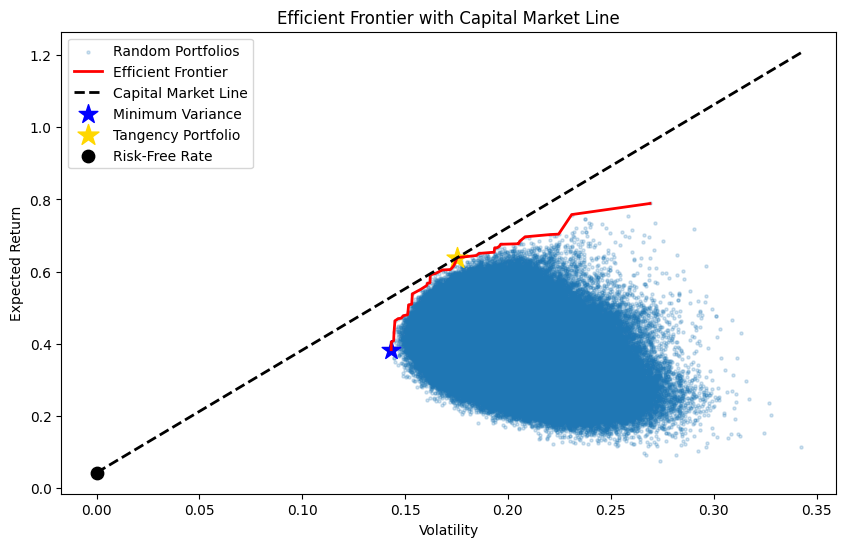

In [41]:
plt.figure(figsize=(10,6))

# Monte Carlo portfolios
plt.scatter(
    portfolios['volatility'],
    portfolios['returns'],
    s=5,
    alpha=0.2,
    label='Random Portfolios'
)

# Efficient Frontier (smoothed version you already built)
plt.plot(
    efficient_frontier['volatility'],
    efficient_frontier['returns'],
    color='red',
    linewidth=2,
    label='Efficient Frontier'
)

# Capital Market Line
plt.plot(
    cml_volatility,
    cml_returns,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Capital Market Line'
)

# Minimum variance portfolio
plt.scatter(
    optimal_portfolio_volatility,
    optimal_portfolio_return,
    color='blue',
    marker='*',
    s=200,
    label='Minimum Variance'
)

# Tangency portfolio
plt.scatter(
    tangency_volatility,
    tangency_return,
    color='gold',
    marker='*',
    s=250,
    label='Tangency Portfolio'
)

# Risk-free point
plt.scatter(
    0,
    rf,
    color='black',
    s=80,
    label='Risk-Free Rate'
)

plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier with Capital Market Line')
plt.legend()
plt.show()